In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import json
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [44]:
df_movies = pd.read_csv('archive1/archive/movies_metadata.csv', sep=',', na_values=[''], quotechar='"', low_memory=False)
df_ratings = pd.read_csv('archive1/archive/ratings_small.csv')

def safe_parse(val):
    if pd.isna(val) or val == '' or val == '[]' or val == '{}':
        return None
    try:
        return ast.literal_eval(val)
    except:
        try:
            return json.loads(val)
        except:
            return None

df_movies['id'] = pd.to_numeric(df_movies['id'], errors='coerce')
df_movies = df_movies.dropna(subset=['id']).copy()
df_movies['id'] = df_movies['id'].astype(int)

df_ratings['movieId'] = pd.to_numeric(df_ratings['movieId'], errors='coerce')
df_ratings = df_ratings.dropna(subset=['movieId']).copy()
df_ratings['movieId'] = df_ratings['movieId'].astype(int)

valid_movie_ids = df_ratings['movieId'].unique()
df_movies = df_movies[df_movies['id'].isin(valid_movie_ids)].copy()

df_movies['belongs_to_collection_parsed'] = df_movies['belongs_to_collection'].apply(safe_parse)
df_movies['genres_parsed'] = df_movies['genres'].apply(safe_parse)
df_movies['has_collection'] = df_movies['belongs_to_collection_parsed'].apply(
    lambda x: 1 if isinstance(x, dict) and x.get('name') else 0
)
df_movies['genre_list'] = df_movies['genres_parsed'].apply(
    lambda x: [g['name'] for g in x] if isinstance(x, list) else []
)
mlb_genres = MultiLabelBinarizer()
genres_onehot = mlb_genres.fit_transform(df_movies['genre_list'])
genres_df = pd.DataFrame(genres_onehot, columns=mlb_genres.classes_, index=df_movies.index)

df_movies['production_companies_parsed'] = df_movies['production_companies'].apply(safe_parse)
def extract_company_names(x):
    if isinstance(x, list):
        return [comp.get('name', '') for comp in x if isinstance(comp, dict) and comp.get('name')]
    return []
df_movies['company_list'] = df_movies['production_companies_parsed'].apply(extract_company_names)
all_companies = df_movies['company_list'].explode()
top_companies = all_companies.value_counts().head(5).index.tolist()
def keep_top_companies(companies):
    return [c for c in companies if c in top_companies] or ['other']
df_movies['company_list_top'] = df_movies['company_list'].apply(keep_top_companies)
mlb_companies = MultiLabelBinarizer()
companies_onehot = mlb_companies.fit_transform(df_movies['company_list_top'])
companies_df = pd.DataFrame(companies_onehot, columns=mlb_companies.classes_, index=df_movies.index)

df_movies['production_countries_parsed'] = df_movies['production_countries'].apply(safe_parse)
def extract_country_names(x):
    if isinstance(x, list):
        return [cnt.get('name', '') for cnt in x if isinstance(cnt, dict) and cnt.get('name')]
    return []
df_movies['country_list'] = df_movies['production_countries_parsed'].apply(extract_country_names)
all_countries = df_movies['country_list'].explode()
top_countries = all_countries.value_counts().head(5).index.tolist()
def keep_top_countries(countries):
    return [c for c in countries if c in top_countries] or ['other']
df_movies['country_list_top'] = df_movies['country_list'].apply(keep_top_countries)
mlb_countries = MultiLabelBinarizer()
countries_onehot = mlb_countries.fit_transform(df_movies['country_list_top'])
countries_df = pd.DataFrame(countries_onehot, columns=mlb_countries.classes_, index=df_movies.index)

df_movies['original_language'] = df_movies['original_language'].fillna('unknown')
top_languages = df_movies['original_language'].value_counts().head(5).index.tolist()
df_movies['language_top'] = df_movies['original_language'].apply(
    lambda x: x if x in top_languages else 'other'
)
lang_onehot = pd.get_dummies(df_movies['language_top'], prefix='lang').astype(int)

df_movies['adult'] = df_movies['adult'].apply(lambda x: 1 if str(x).lower() == 'true' else 0)
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')
df_movies['release_year'] = df_movies['release_date'].dt.year.fillna(0).astype(int)
df_movies['runtime'] = pd.to_numeric(df_movies['runtime'], errors='coerce').fillna(0)
df_movies['popularity'] = pd.to_numeric(df_movies['popularity'], errors='coerce').fillna(0)
df_movies['budget'] = pd.to_numeric(df_movies['budget'], errors='coerce').fillna(0)
df_movies['revenue'] = pd.to_numeric(df_movies['revenue'], errors='coerce').fillna(0)

movie_features = pd.concat([
    df_movies[['id', 'has_collection', 'adult', 'vote_average', 'vote_count',
               'runtime', 'release_year', 'popularity', 'budget', 'revenue']],
    genres_df,
    companies_df,
    countries_df,
    lang_onehot
], axis=1)

df_ratings = df_ratings.merge(movie_features, left_on='movieId', right_on='id', how='inner')

df_ratings = df_ratings.drop(columns=['id', 'movieId'], errors='ignore')

user_rating_counts = df_ratings.groupby('userId').size()
active_users = user_rating_counts[user_rating_counts >= 2].index
df_ratings = df_ratings[df_ratings['userId'].isin(active_users)]

user_profile = df_ratings.groupby('userId').mean(numeric_only=True)

print(user_profile.columns.tolist())

['rating', 'timestamp', 'has_collection', 'adult', 'vote_average', 'vote_count', 'runtime', 'release_year', 'popularity', 'budget', 'revenue', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'Metro-Goldwyn-Mayer (MGM)', 'Paramount Pictures', 'Twentieth Century Fox Film Corporation', 'Universal Pictures', 'Warner Bros.', 'other', 'France', 'Germany', 'Italy', 'United Kingdom', 'United States of America', 'other', 'lang_de', 'lang_en', 'lang_fr', 'lang_it', 'lang_ja', 'lang_other']


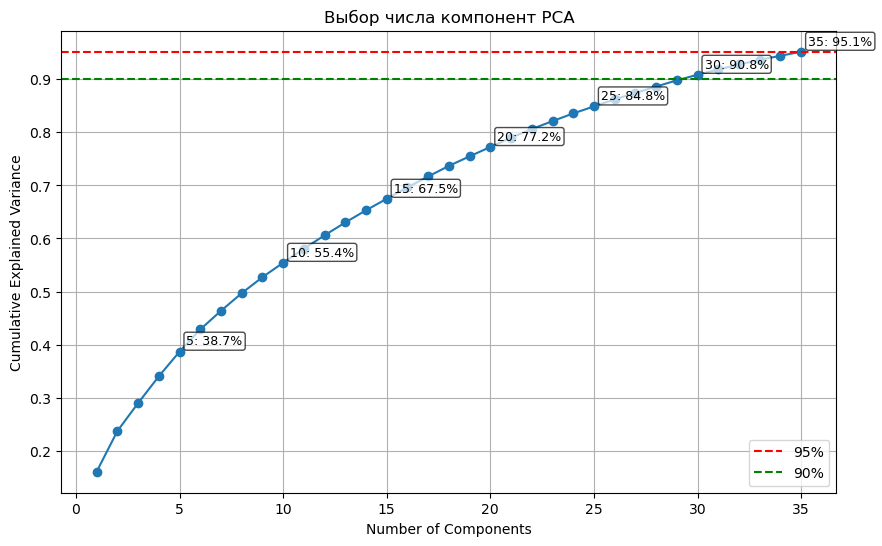

Для 95% дисперсии нужно 35 компонент
Для 90% дисперсии нужно 30 компонент


In [45]:
scaler = StandardScaler()
X_user_scaled = scaler.fit_transform(user_profile)

n_components = 35
pca = PCA(n_components=n_components, random_state=42)
X_user_pca = pca.fit_transform(X_user_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid(True)

step = 5
indices = range(step - 1, n_components, step)
for i in indices:
    x = components[i]
    y = cum_var[i]
    label = f'{x}: {y:.1%}'
    plt.annotate(label,
                 xy=(x, y),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.show()

n_95 = np.argmax(cum_var >= 0.95) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Для 95% дисперсии нужно {n_95} компонент")
print(f"Для 90% дисперсии нужно {n_90} компонент")

K =  2 | Silhouette = 0.1035
K =  3 | Silhouette = 0.0859
K =  4 | Silhouette = 0.0799
K =  5 | Silhouette = 0.0785
K =  6 | Silhouette = 0.0801
K =  7 | Silhouette = 0.0818
K =  8 | Silhouette = 0.0640
K =  9 | Silhouette = 0.0701
K = 10 | Silhouette = 0.0523
K = 11 | Silhouette = 0.0685
K = 12 | Silhouette = 0.0515


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

K = 13 | Silhouette = 0.0528
K = 14 | Silhouette = 0.0476
K = 15 | Silhouette = 0.0423
K = 16 | Silhouette = 0.0490
K = 17 | Silhouette = 0.0400
K = 18 | Silhouette = 0.0200
K = 19 | Silhouette = 0.0200
K = 20 | Silhouette = 0.0197
K = 21 | Silhouette = 0.0086
K = 22 | Silhouette = 0.0077
K = 23 | Silhouette = 0.0324
K = 24 | Silhouette = 0.0098


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

K = 25 | Silhouette = 0.0071
K = 26 | Silhouette = 0.0098
K = 27 | Silhouette = 0.0019
K = 28 | Silhouette = 0.0028
K = 29 | Silhouette = 0.0037
K = 30 | Silhouette = -0.0010
K = 31 | Silhouette = -0.0026
K = 32 | Silhouette = -0.0016
K = 33 | Silhouette = 0.0003
K = 34 | Silhouette = -0.0043


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

K = 35 | Silhouette = -0.0035
K = 36 | Silhouette = -0.0090
K = 37 | Silhouette = -0.0021
K = 38 | Silhouette = -0.0010
K = 39 | Silhouette = -0.0065
K = 40 | Silhouette = -0.0077

Оптимальное K для пользователей = 2 (силуэт = 0.1035)


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

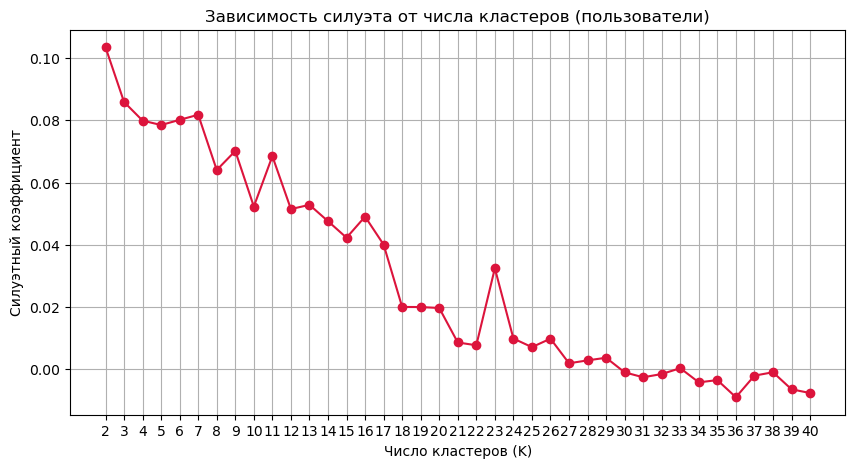

In [46]:
sample_size = min(25000, X_user_pca.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_user_pca.shape[0], size=sample_size, replace=False)
X_sample = X_user_pca[sample_idx]

K_range = range(2, 41)
silhouette_scores = []
best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_user_pca)
    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | Silhouette = {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное K для пользователей = {best_k} (силуэт = {best_score:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='crimson')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Зависимость силуэта от числа кластеров (пользователи)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [47]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_user_pca)
user_profile['cluster'] = cluster_labels

print("\nРаспределение пользователей по кластерам:")
print(user_profile['cluster'].value_counts().sort_index())


Распределение пользователей по кластерам:
cluster
0    314
1    357
Name: count, dtype: int64


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


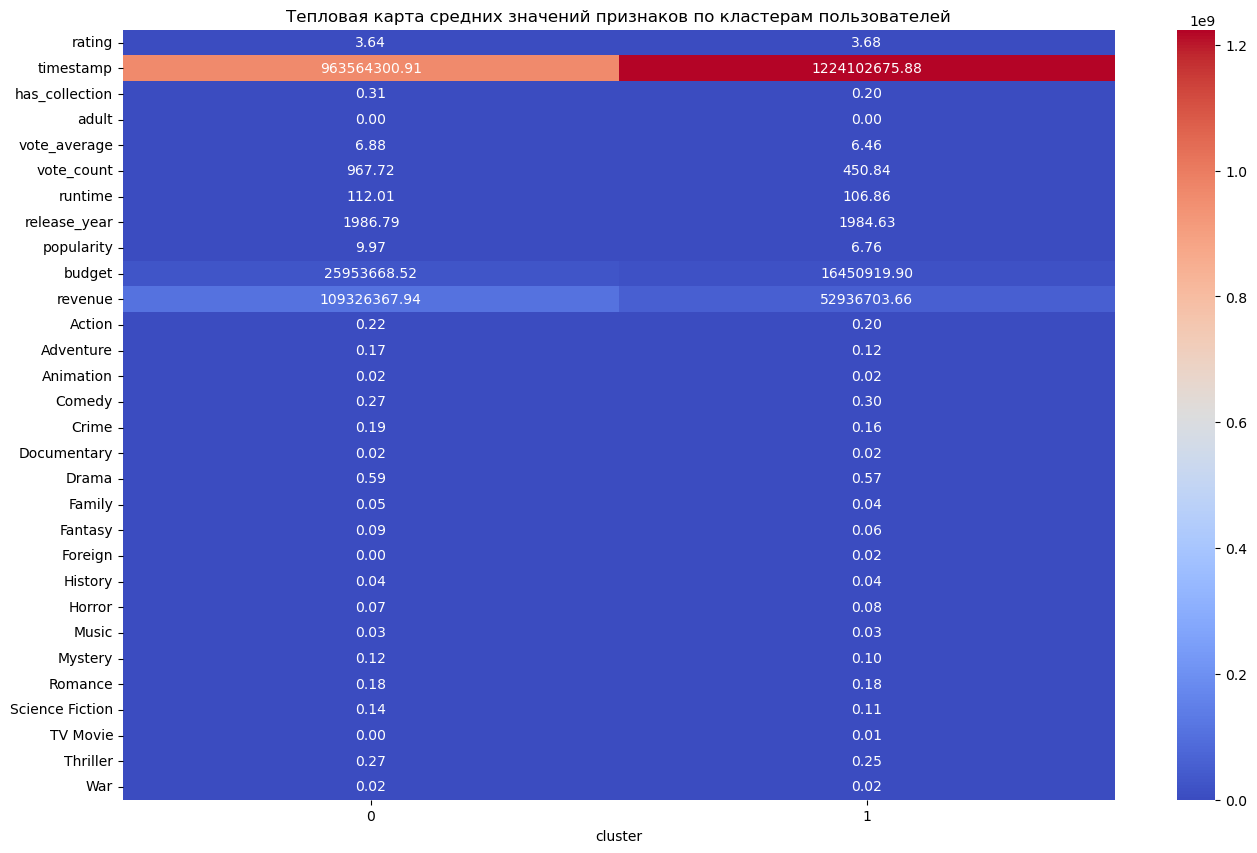

In [48]:
cluster_profile = user_profile.groupby('cluster').mean()

plt.figure(figsize=(16, 10))
sns.heatmap(cluster_profile.iloc[:, :30].T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам пользователей')
plt.show()

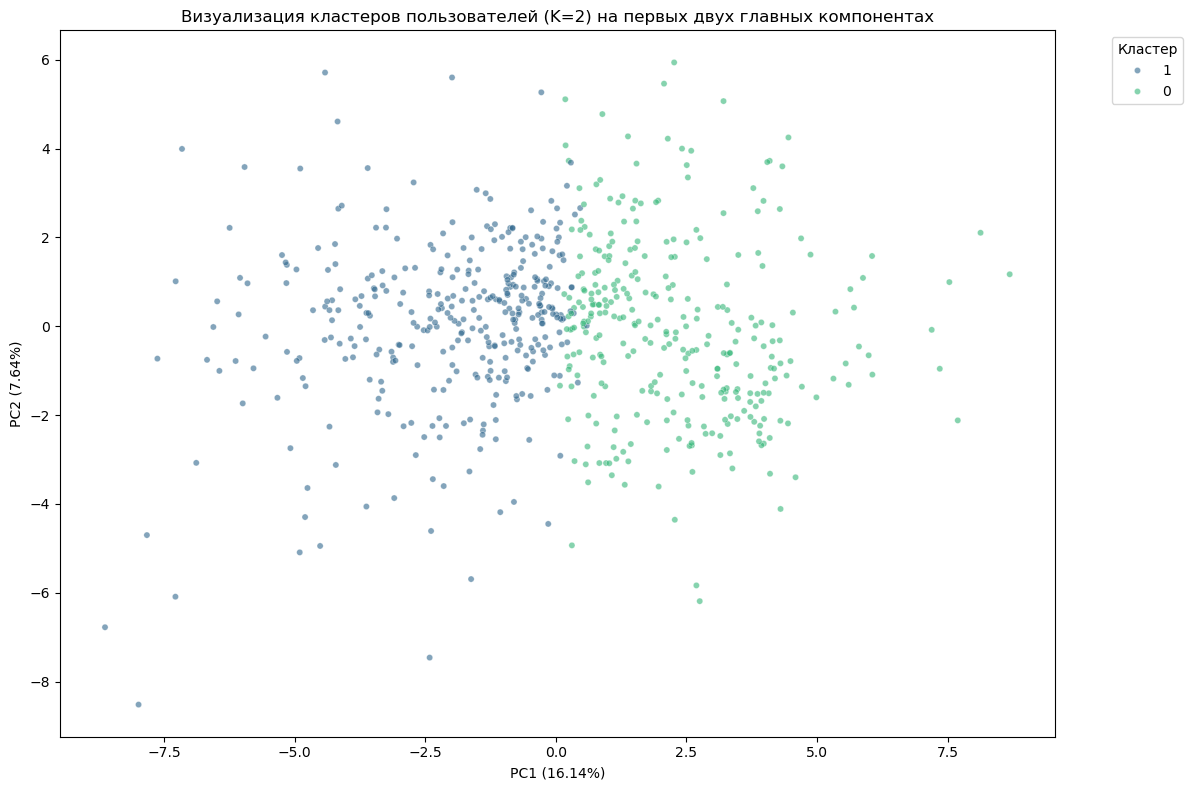

In [49]:
pca_df = pd.DataFrame({
    'PC1': X_user_pca[:, 0],
    'PC2': X_user_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster', palette='viridis', alpha=0.6, s=20)
plt.title(f'Визуализация кластеров пользователей (K={best_k}) на первых двух главных компонентах')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()